# Section 1 — OSS Model Analysis

Unified analysis notebook for **all model sizes**.  
Change `MODEL_SIZE` below to switch between `very_small`, `small`, `medium`, `big`.

In [20]:

MODEL_SIZE = "medium"   # one of: "very_small", "small", "medium", "big"

import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({"font.size": 22})
sns.set(font_scale=2.4)

LOGS_ROOT = "../../.logs/"
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

SIZE_LABEL = MODEL_SIZE.replace("_", " ").title()  # e.g. "Very Small"
print(f"Analysing model size: {SIZE_LABEL}")

Analysing model size: Medium


In [21]:
# Scans no_retries/{MODEL_SIZE} for model folder names like "modelA_vs_modelB"
def detect_agents(logs_root, model_size):
    agents = set()
    for game_prefix in ["buysell", "trading", "ultimatum"]:
        scan_dir = os.path.join(logs_root, f"section_one/{game_prefix}_section_one/no_retries/{model_size}")
        if not os.path.isdir(scan_dir):
            continue
        for root, dirs, files in os.walk(scan_dir):
            if "game_state.json" not in files:
                continue
            try:
                with open(os.path.join(root, "game_state.json")) as f:
                    data = json.load(f)
                for p in data["players"]:
                    agents.add(p.get("model_id", p.get("model", "unknown")))
            except Exception:
                pass
    return sorted(agents)

_raw_agents = detect_agents(LOGS_ROOT, MODEL_SIZE)

# Build clean-name mapping: "org/Model-Name" vs "Model-Name"
def clean_name(full_id):
    name = full_id.split("/")[-1]
    # Remove common suffixes for brevity
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

AGENTS = _raw_agents
AGENTS_CLEAN_NAMES = [clean_name(a) for a in AGENTS]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

print(f"Detected {len(AGENTS)} agents:")
for full, short in zip(AGENTS, AGENTS_CLEAN_NAMES):
    print(f"  {full}  vs  {short}")

Detected 3 agents:
  Qwen/Qwen3.5-27B  vs  Qwen3.5-27B
  google/gemma-3-27b-it  vs  gemma-3-27b-it
  mistralai/Mistral-Small-3.2-24B-Instruct-2506  vs  Mistral-Small-3.2-24B-2506


## Utility Functions

In [22]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def scan_games(log_dir):
    """Scan games including incomplete ones — used for completion-rate & retry analysis."""
    rows = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            states = data["game_state"]
            last = states[-1]
            completed = last.get("current_iteration") == "END"
            players = data["players"]
            model_1 = players[0].get("model_id", players[0].get("model", "unknown"))
            model_2 = players[1].get("model_id", players[1].get("model", "unknown"))

            turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
            retries_per_turn = [s.get("parse_retries", 0) for s in turn_states]
            total_retries = sum(r for r in retries_per_turn if isinstance(r, int))
            max_retries_in_game = max((r for r in retries_per_turn if isinstance(r, int)), default=0)

            rows.append({
                "path": path,
                "model_1": model_1,
                "model_2": model_2,
                "completed": completed,
                "num_turns": len(turn_states),
                "total_retries": total_retries,
                "max_retries_in_game": max_retries_in_game,
                "retries_per_turn": retries_per_turn,
            })
        except Exception:
            pass
    return pd.DataFrame(rows)


def resource_value(res):
    return sum(res["_value"].values())


def replace_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

In [23]:
def game_dir(game_prefix, condition="no_retries"):
    return os.path.join(LOGS_ROOT, f"section_one/{game_prefix}_section_one/{condition}/{MODEL_SIZE}")

GAME_PREFIXES = ["buysell", "trading", "ultimatum"]
GAME_NAMES    = ["BuySell", "Trading", "Ultimatum"]

# Verify which paths exist
for prefix, name in zip(GAME_PREFIXES, GAME_NAMES):
    bl = game_dir(prefix, "no_retries")
    rt = game_dir(prefix, "retry3")
    print(f"{name}:")
    print(f"  baseline : {'yes' if os.path.isdir(bl) else 'no  ' + bl}")
    print(f"  retry3   : {'yes' if os.path.isdir(rt) else 'no  ' + rt}")

BuySell:
  baseline : yes
  retry3   : yes
Trading:
  baseline : yes
  retry3   : yes
Ultimatum:
  baseline : yes
  retry3   : yes


---
## Game Completion Rates

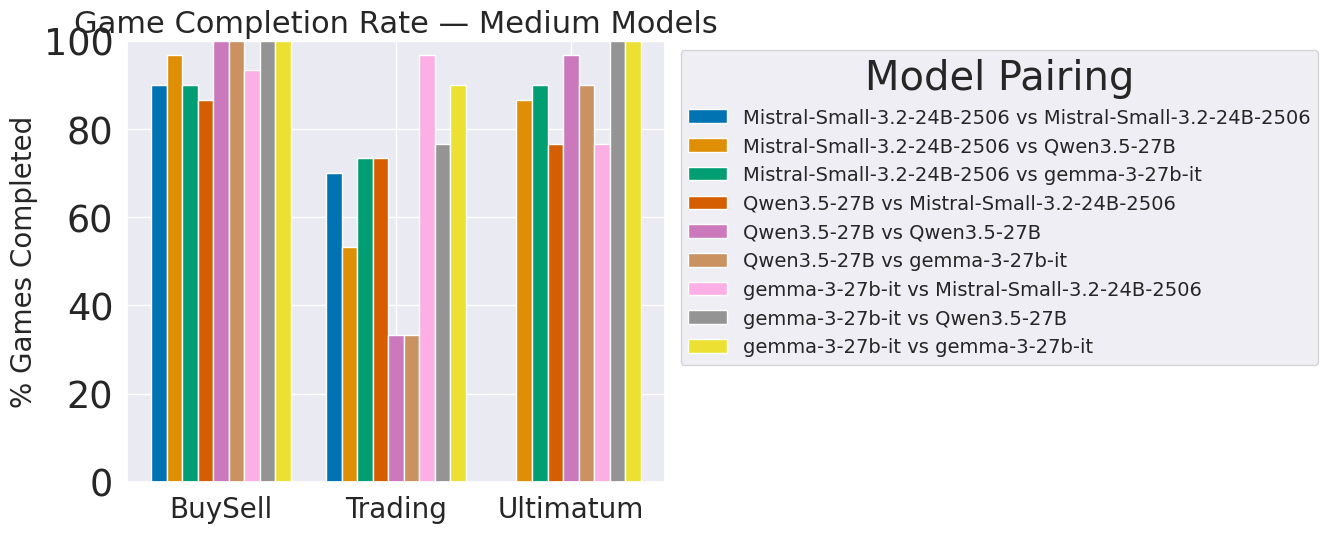

In [24]:
def load_completion_stats(log_dirs):
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "model_2": players[1].get("model_id", players[1].get("model", "unknown")),
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


# Use ONLY the no_retries (baseline) data for section-1 analysis
log_dirs = {name: game_dir(prefix, "no_retries") for prefix, name in zip(GAME_PREFIXES, GAME_NAMES)}

df_raw = load_completion_stats(log_dirs)
df_raw = replace_names(df_raw)
df_raw["pairing"] = df_raw["model_1"] + " vs " + df_raw["model_2"]

agg = df_raw.groupby(["game", "pairing"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = agg["game"].unique()
pairings = sorted(agg["pairing"].unique())
x = np.arange(len(games))
width = 0.8 / max(len(pairings), 1)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("colorblind", len(pairings))

for i, pairing in enumerate(pairings):
    sub = agg[agg["pairing"] == pairing].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    ax.bar(x + i * width, vals, width, label=pairing, color=colors[i])

ax.set_xticks(x + width * (len(pairings) - 1) / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("% Games Completed", fontsize=20)
ax.set_title(f"Game Completion Rate — {SIZE_LABEL} Models", fontsize=22)
ax.set_ylim(0, 100)
ax.legend(title="Model Pairing", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_completion_rate.pdf", bbox_inches="tight")
plt.show()

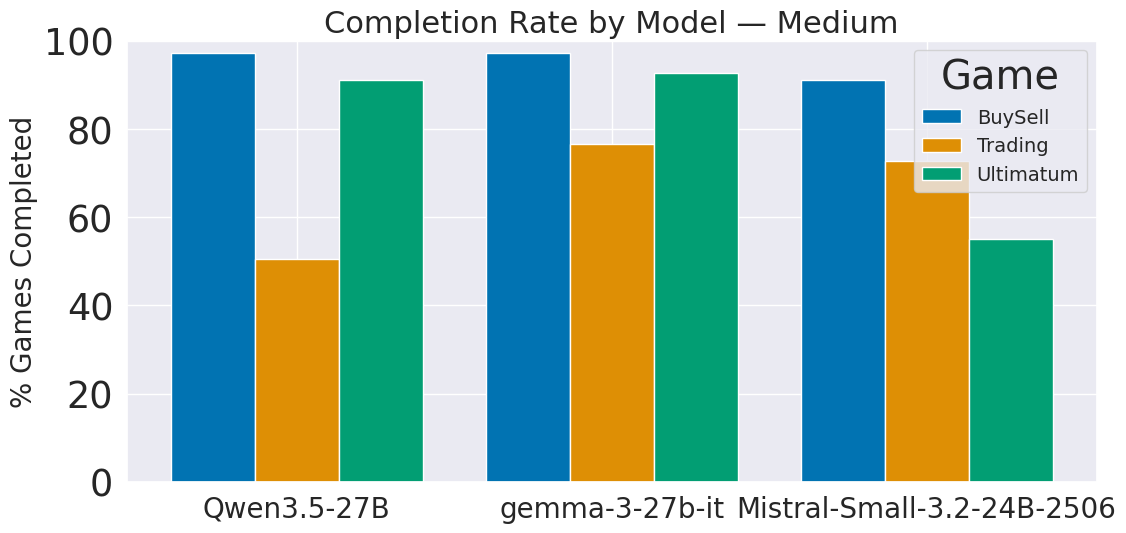

In [25]:
#  Per-model completion rate 
df_m1 = df_raw[["game", "model_1", "completed"]].rename(columns={"model_1": "model"})
df_m2 = df_raw[["game", "model_2", "completed"]].rename(columns={"model_2": "model"})
agg_model = (
    pd.concat([df_m1, df_m2])
    .groupby(["game", "model"])
    .agg(total=("completed", "count"), completed=("completed", "sum"))
    .reset_index()
)
agg_model["pct"] = agg_model["completed"] / agg_model["total"] * 100

games_list = sorted(agg_model["game"].unique())
models_list = AGENTS_CLEAN_NAMES
x2 = np.arange(len(models_list))
width2 = 0.8 / max(len(games_list), 1)

fig2, ax2 = plt.subplots(figsize=(12, 6))
game_colors = sns.color_palette("colorblind", len(games_list))

for i, game in enumerate(games_list):
    sub = agg_model[agg_model["game"] == game].set_index("model")
    vals = [sub.loc[m, "pct"] if m in sub.index else 0 for m in models_list]
    ax2.bar(x2 + i * width2, vals, width2, label=game, color=game_colors[i])

ax2.set_xticks(x2 + width2 * (len(games_list) - 1) / 2)
ax2.set_xticklabels(models_list, fontsize=20)
ax2.set_ylabel("% Games Completed", fontsize=20)
ax2.set_title(f"Completion Rate by Model — {SIZE_LABEL}", fontsize=22)
ax2.set_ylim(0, 100)
ax2.legend(title="Game", fontsize=14)
fig2.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_completion_rate_by_model.pdf", bbox_inches="tight")
plt.show()

---
## Trading Game

In [26]:
records = load_games_from_dir(game_dir("trading", "no_retries"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_names(pd.DataFrame(rows))
print(f"Total trading games: {len(trading_df)}")
print("Games per pairing:")
print(trading_df.groupby(["model_1", "model_2"]).size().to_string())

Found 180 completed games in ../../.logs/section_one/trading_section_one/no_retries/medium
Total trading games: 180
Games per pairing:
model_1                     model_2                   
Mistral-Small-3.2-24B-2506  Mistral-Small-3.2-24B-2506    21
                            Qwen3.5-27B                   16
                            gemma-3-27b-it                22
Qwen3.5-27B                 Mistral-Small-3.2-24B-2506    22
                            Qwen3.5-27B                   10
                            gemma-3-27b-it                10
gemma-3-27b-it              Mistral-Small-3.2-24B-2506    29
                            Qwen3.5-27B                   23
                            gemma-3-27b-it                27


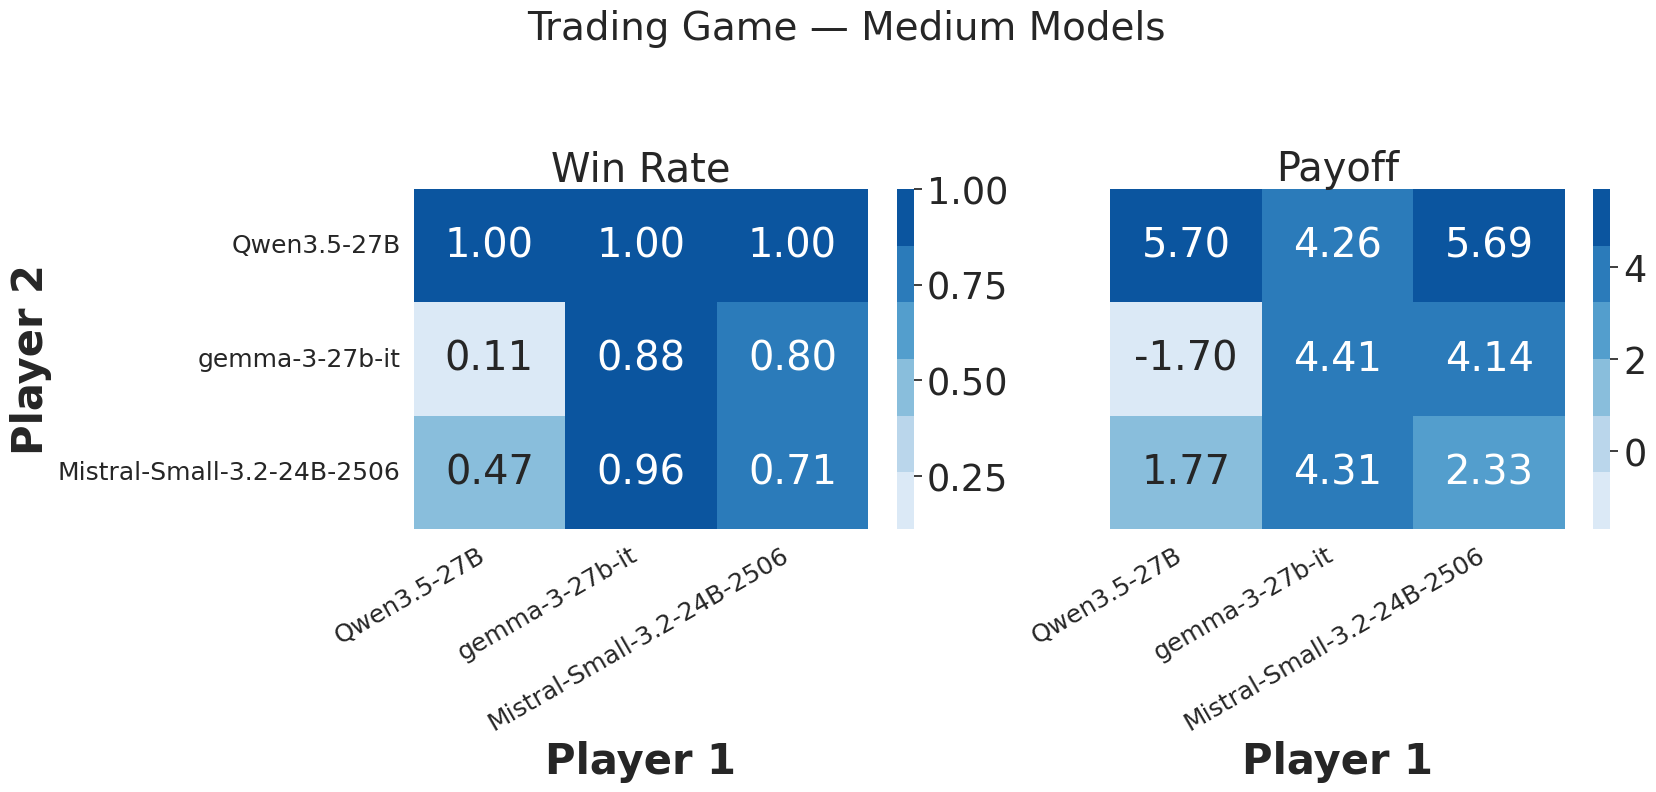

In [27]:
def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = trading_aggregation(trading_df)

fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

# Win Rate heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="win_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_title("Win Rate")
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="resource_delta_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle(f"Trading Game — {SIZE_LABEL} Models", fontsize=28, y=1.02)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_trading.pdf", bbox_inches="tight")
plt.show()

---
## Ultimatum Game

In [28]:
records = load_games_from_dir(game_dir("ultimatum", "no_retries"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_names(pd.DataFrame(rows))
ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

print(f"Total ultimatum games: {len(ultimatum_df)}")
print("\nGames per pairing:")
print(ultimatum_df.groupby(["model_1", "model_2"]).size().to_string())
print("\nNo-deal rate per pairing:")
no_deal = ultimatum_df.copy()
no_deal["no_deal"] = (no_deal["resource_delta_1"] == 0) & (no_deal["resource_delta_2"] == 0)
print(no_deal.groupby(["model_1", "model_2"])["no_deal"].mean().to_string())

Found 215 completed games in ../../.logs/section_one/ultimatum_section_one/no_retries/medium
Total ultimatum games: 215

Games per pairing:
model_1                     model_2                   
Mistral-Small-3.2-24B-2506  Qwen3.5-27B                   26
                            gemma-3-27b-it                27
Qwen3.5-27B                 Mistral-Small-3.2-24B-2506    23
                            Qwen3.5-27B                   29
                            gemma-3-27b-it                27
gemma-3-27b-it              Mistral-Small-3.2-24B-2506    23
                            Qwen3.5-27B                   30
                            gemma-3-27b-it                30

No-deal rate per pairing:
model_1                     model_2                   
Mistral-Small-3.2-24B-2506  Qwen3.5-27B                   0.000000
                            gemma-3-27b-it                0.074074
Qwen3.5-27B                 Mistral-Small-3.2-24B-2506    0.130435
                            Qwen3.

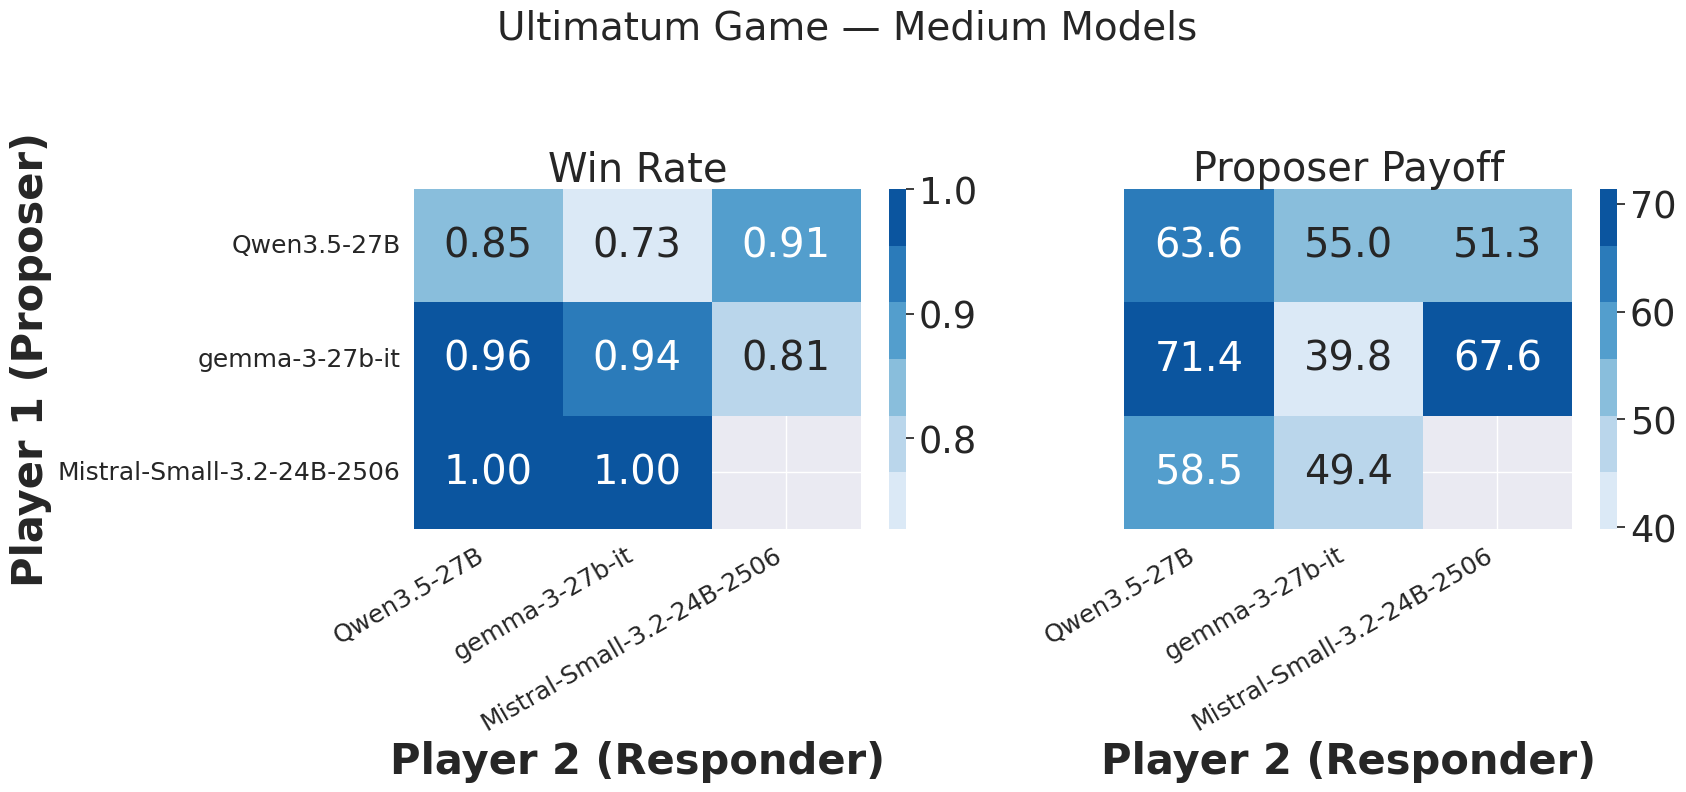

In [29]:
def ultimatum_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = ultimatum_aggregation(ultimatum_df)

fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

# Win Rate heatmap (P1 = proposer)
local = aggregated.pivot(index="model_1", columns="model_2", values="win_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_title("Win Rate")
p1.set_ylabel("Player 1 (Proposer)", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="resource_delta_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".1f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p2.set_title("Proposer Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle(f"Ultimatum Game — {SIZE_LABEL} Models", fontsize=28, y=1.02)
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_ultimatum.pdf", bbox_inches="tight")
plt.show()

---
## Buy-Sell Game

In [30]:
records = load_games_from_dir(game_dir("buysell", "no_retries"))

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s["player_valuation"]
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_names(pd.DataFrame(rows))

print(f"Total buy-sell games: {len(buysell_df)}")
print(f"\nAvailable seller valuations: {sorted(buysell_df['vals1'].unique())}")

gb = buysell_df.groupby("vals1")
groups = {k: v.copy() for k, v in gb}

print("\nGames per valuation × pairing:")
for val, gdf in sorted(groups.items()):
    print(f"  Seller valuation={val}:")
    print(gdf.groupby(["model_1", "model_2"]).size().to_string())

Found 257 completed games in ../../.logs/section_one/buysell_section_one/no_retries/medium
Total buy-sell games: 257

Available seller valuations: [40]

Games per valuation × pairing:
  Seller valuation=40:
model_1                     model_2                   
Mistral-Small-3.2-24B-2506  Mistral-Small-3.2-24B-2506    27
                            Qwen3.5-27B                   29
                            gemma-3-27b-it                27
Qwen3.5-27B                 Mistral-Small-3.2-24B-2506    26
                            Qwen3.5-27B                   30
                            gemma-3-27b-it                30
gemma-3-27b-it              Mistral-Small-3.2-24B-2506    28
                            Qwen3.5-27B                   30
                            gemma-3-27b-it                30


Seller at 40 (buyer at 60): 257 games
Filtered 0 outlier games


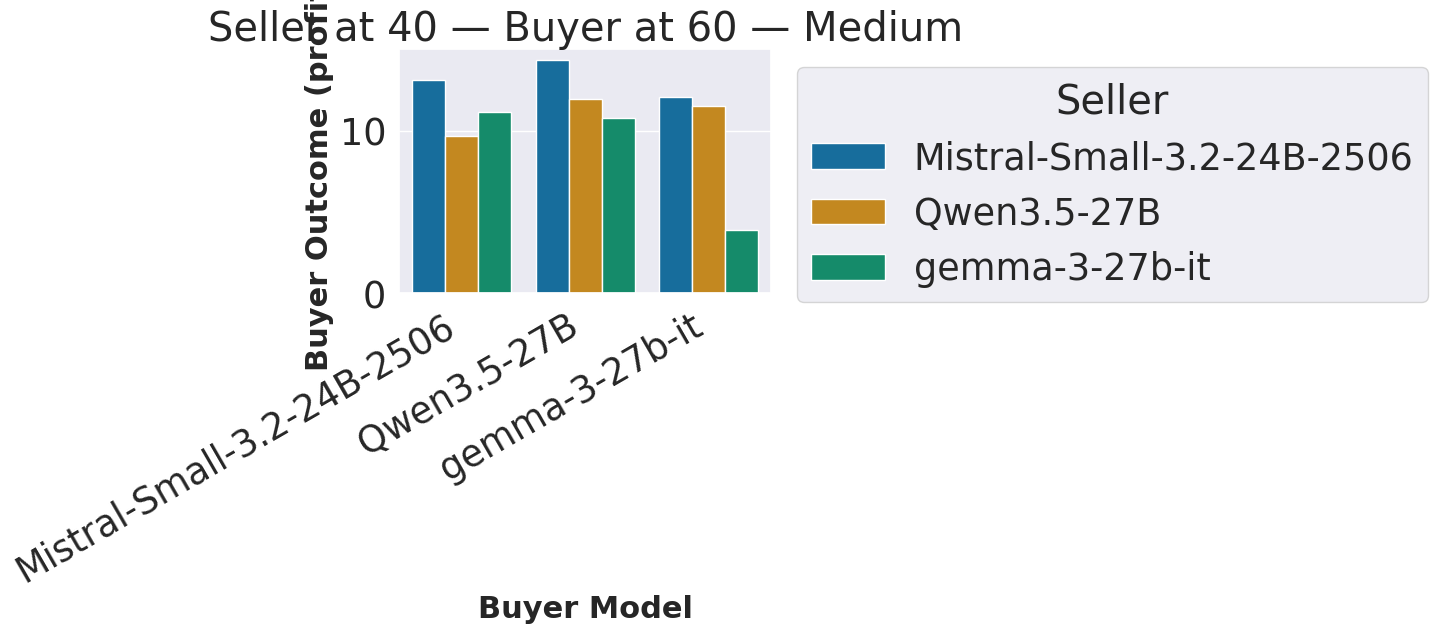

                    seller                      buyer  outcome_mean  outcome_sem  n
Mistral-Small-3.2-24B-2506 Mistral-Small-3.2-24B-2506     13.111111     1.155112 27
Mistral-Small-3.2-24B-2506                Qwen3.5-27B     14.310345     1.215766 29
Mistral-Small-3.2-24B-2506             gemma-3-27b-it     12.037037     1.608809 27
               Qwen3.5-27B Mistral-Small-3.2-24B-2506      9.692308     1.020964 26
               Qwen3.5-27B                Qwen3.5-27B     11.966667     0.785623 30
               Qwen3.5-27B             gemma-3-27b-it     11.533333     1.009988 30
            gemma-3-27b-it Mistral-Small-3.2-24B-2506     11.142857     1.198229 28
            gemma-3-27b-it                Qwen3.5-27B     10.800000     0.523911 30
            gemma-3-27b-it             gemma-3-27b-it      3.900000     1.029842 30


In [31]:
seller_at_40 = groups.get(40, pd.DataFrame())
print(f"Seller at 40 (buyer at 60): {len(seller_at_40)} games")

# Filter broken games: buyer profit ∈ [-100, 60]
valid = seller_at_40[
    (seller_at_40["outcome_2"] >= -100) & (seller_at_40["outcome_2"] <= 60)
]
print(f"Filtered {len(seller_at_40) - len(valid)} outlier games")

agg = (
    valid.groupby(["model_1", "model_2"])["outcome_2"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
agg.columns = ["seller", "buyer", "outcome_mean", "outcome_sem", "n"]
agg = agg[agg["n"] >= 2]

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=agg, x="buyer", y="outcome_mean", hue="seller",
    palette="colorblind", capsize=0.1, ax=ax,
)
ax.set_ylabel("Buyer Outcome (profit)", fontdict=dict(weight="bold", size=22))
ax.set_xlabel("Buyer Model", fontdict=dict(weight="bold", size=22))
ax.set_title(f"Seller at 40 — Buyer at 60 — {SIZE_LABEL}")
ax.legend(title="Seller", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout()
plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_seller_at_40.pdf", bbox_inches="tight")
plt.show()

print(agg.to_string(index=False))

### Buy-Sell — Outcome Heatmaps

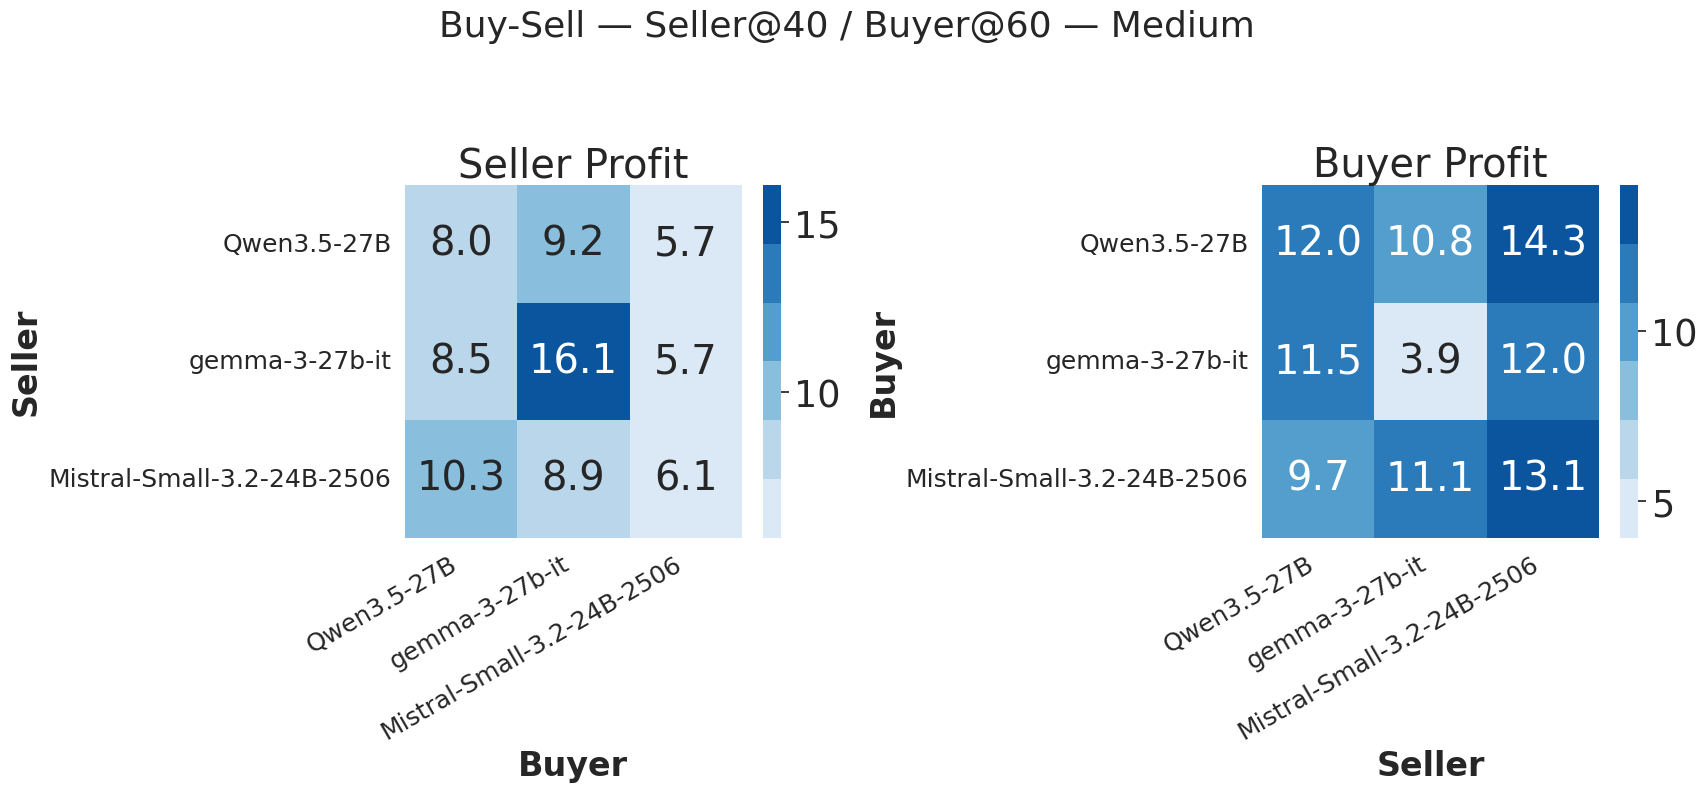

In [32]:
if len(valid) > 0:
    fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

    for ax, (col, title) in zip(axs, [("outcome_1", "Seller Profit"), ("outcome_2", "Buyer Profit")]):
        pivot_data = valid.groupby(["model_1", "model_2"])[col].mean().reset_index()
        pivot = pivot_data.pivot(index="model_2", columns="model_1", values=col)
        pivot = pivot.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

        sns.heatmap(pivot, annot=True, fmt=".1f", cmap=colormap, ax=ax)
        ax.set_title(title)
        ax.set_ylabel(
            "Buyer" if col == "outcome_2" else "Seller",
            fontdict=dict(weight="bold", size=24),
        )
        ax.set_xlabel(
            "Seller" if col == "outcome_2" else "Buyer",
            fontdict=dict(weight="bold", size=24),
        )
        ax.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
        ax.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

    fig.suptitle(f"Buy-Sell — Seller@40 / Buyer@60 — {SIZE_LABEL}", fontsize=26, y=1.02)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_buysell_heatmap.pdf", bbox_inches="tight")
    plt.show()

---
# Ablation: Parse-Error Self-Correction (Retry Feedback)

Compares game completion rates **with** and **without** a retry mechanism that feeds
parse errors back to the model and lets it correct its response.

- **Baseline** (`no_retries`): parse errors crash the game immediately
- **Retry3** (`retry3`): model gets up to 3 attempts to fix its output

In [33]:
#  Load baseline + retry data for the current MODEL_SIZE 

all_rows = []
for prefix, name in zip(GAME_PREFIXES, GAME_NAMES):
    bl_dir = game_dir(prefix, "no_retries")
    rt_dir = game_dir(prefix, "retry3")

    if os.path.isdir(bl_dir):
        bl = scan_games(bl_dir)
        bl["condition"] = "Baseline"
        bl["game"] = name
        all_rows.append(bl)

    if os.path.isdir(rt_dir):
        rt = scan_games(rt_dir)
        rt["condition"] = "Retry (n=3)"
        rt["game"] = name
        all_rows.append(rt)

if all_rows:
    df_retry_all = pd.concat(all_rows, ignore_index=True)
    df_retry_all = replace_names(df_retry_all)
    df_retry_all["pairing"] = df_retry_all["model_1"] + "\nvs " + df_retry_all["model_2"]
    print(f"Total game files loaded: {len(df_retry_all)}")
    print(df_retry_all.groupby(["game", "condition"]).agg(
        total=("completed", "count"),
        completed=("completed", "sum"),
    ).to_string())
else:
    df_retry_all = pd.DataFrame()
    print("No retry data found for this model size.")

Total game files loaded: 1601
                       total  completed
game      condition                    
BuySell   Baseline       270        257
          Retry (n=3)    270        233
Trading   Baseline       270        180
          Retry (n=3)    251        197
Ultimatum Baseline       270        215
          Retry (n=3)    270        227


### Completion Rate: Baseline vs Retry

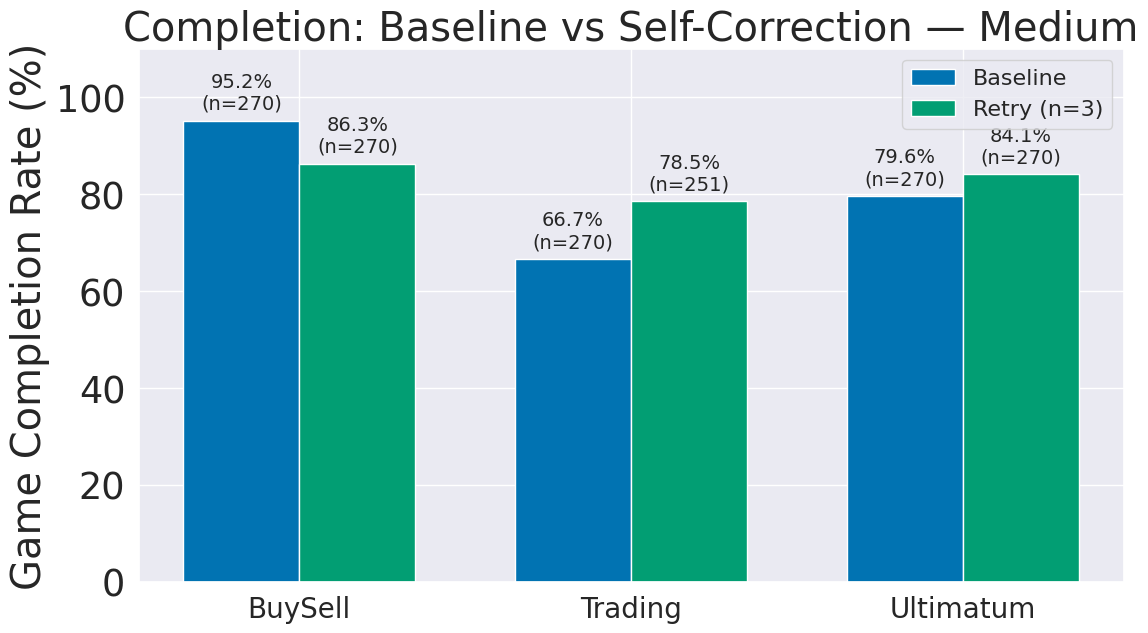

In [34]:
if len(df_retry_all) > 0:
    agg = df_retry_all.groupby(["game", "condition"]).agg(
        total=("completed", "count"),
        completed=("completed", "sum"),
    ).reset_index()
    agg["pct"] = agg["completed"] / agg["total"] * 100

    games = sorted(agg["game"].unique())
    conditions = ["Baseline", "Retry (n=3)"]
    x = np.arange(len(games))
    width = 0.35
    cond_colors = {"Baseline": sns.color_palette("colorblind")[0],
                   "Retry (n=3)": sns.color_palette("colorblind")[2]}

    fig, ax = plt.subplots(figsize=(12, 7))
    for i, cond in enumerate(conditions):
        sub = agg[agg["condition"] == cond].set_index("game")
        vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
        totals = [f'n={int(sub.loc[g, "total"])}' if g in sub.index else "" for g in games]
        bars = ax.bar(x + i * width, vals, width, label=cond, color=cond_colors[cond])
        for bar, val, total in zip(bars, vals, totals):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
                    f"{val:.1f}%\n({total})", ha="center", va="bottom", fontsize=14)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(games, fontsize=20)
    ax.set_ylabel("Game Completion Rate (%)")
    ax.set_title(f"Completion: Baseline vs Self-Correction — {SIZE_LABEL}")
    ax.set_ylim(0, 110)
    ax.legend(fontsize=16)
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_retry_completion_rate.pdf", bbox_inches="tight")
    plt.show()

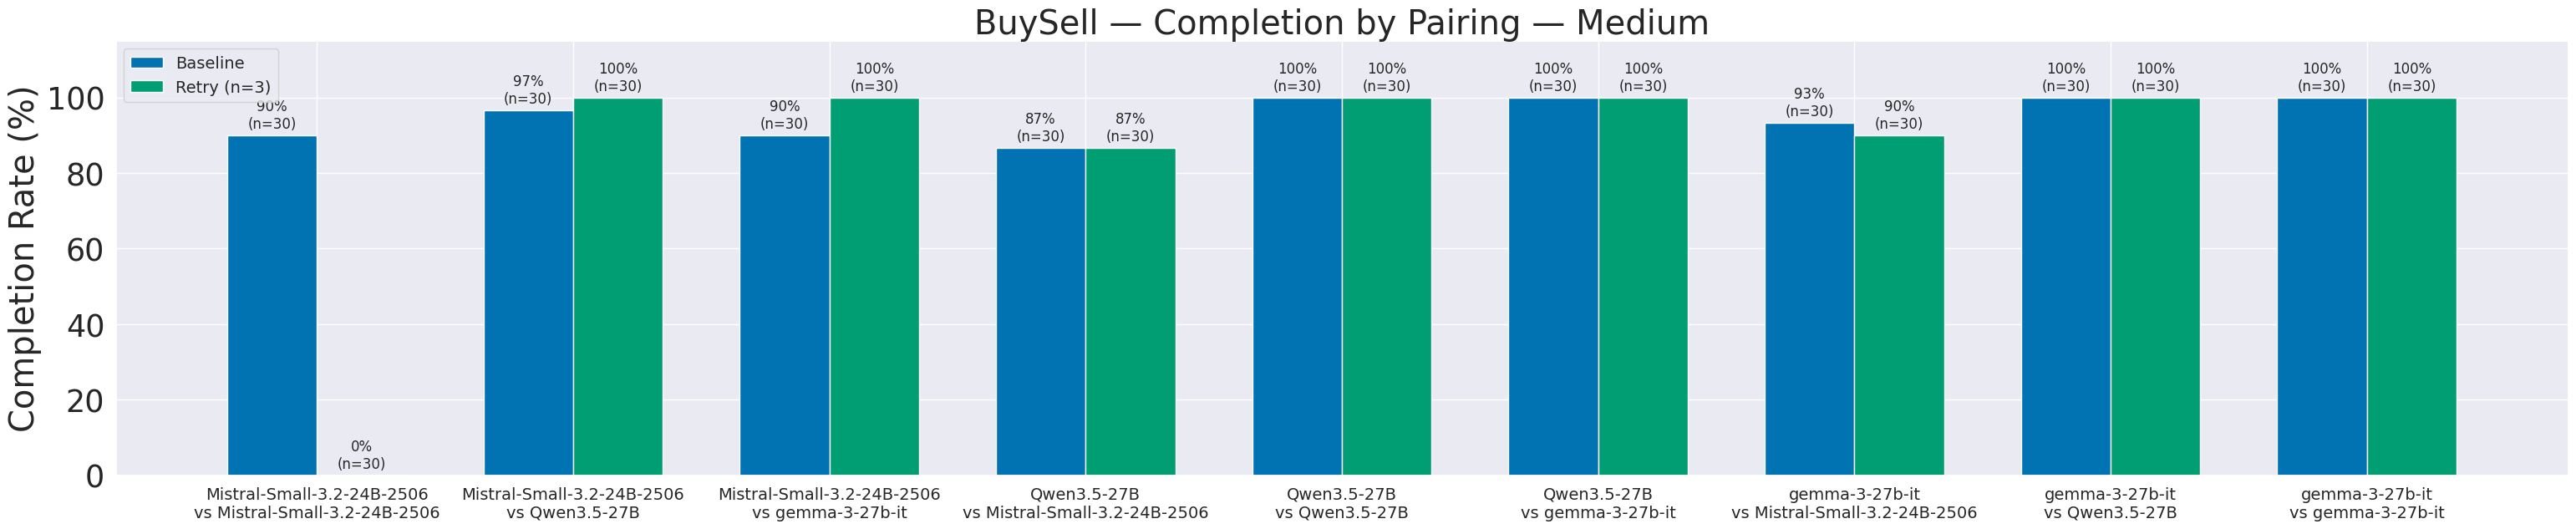

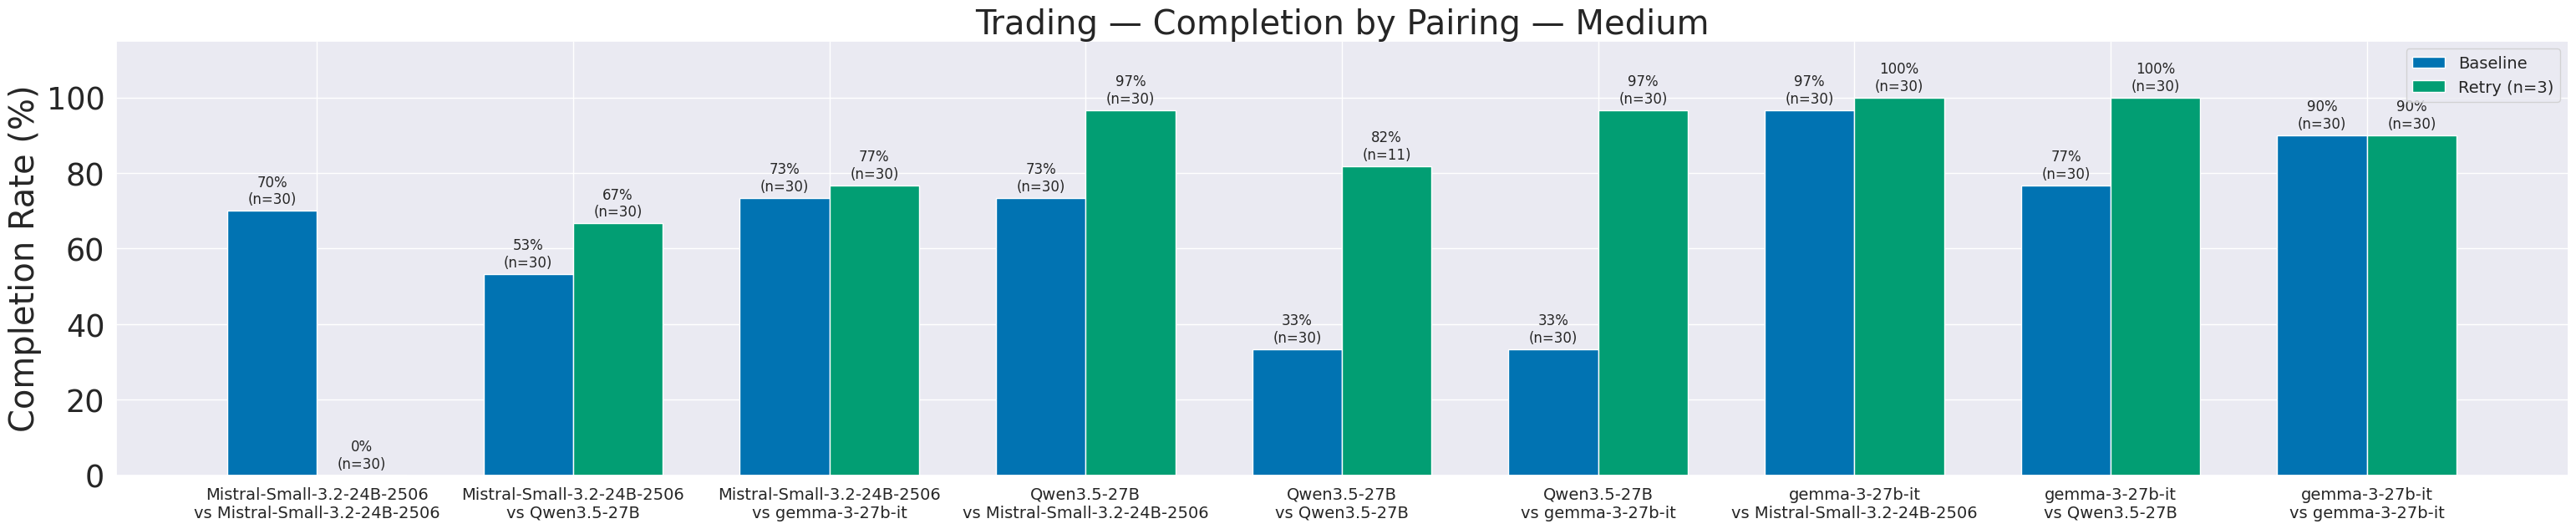

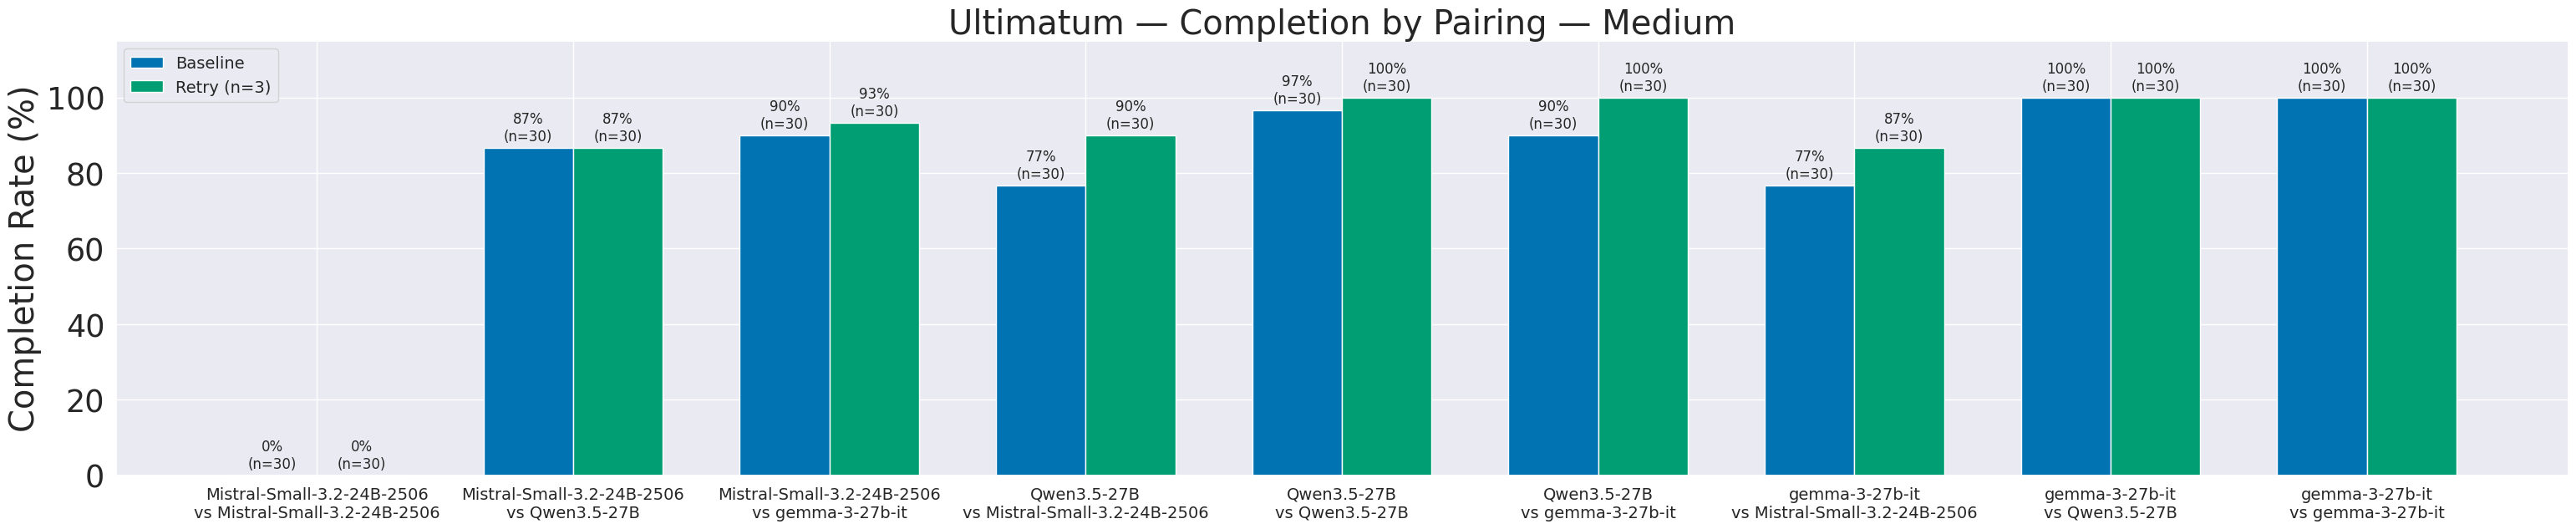

In [35]:
#  Completion rate by pairing 
if len(df_retry_all) > 0:
    agg_pair = df_retry_all.groupby(["game", "condition", "pairing"]).agg(
        total=("completed", "count"),
        completed=("completed", "sum"),
    ).reset_index()
    agg_pair["pct"] = agg_pair["completed"] / agg_pair["total"] * 100

    conditions = ["Baseline", "Retry (n=3)"]
    cond_colors = {"Baseline": sns.color_palette("colorblind")[0],
                   "Retry (n=3)": sns.color_palette("colorblind")[2]}
    width = 0.35

    for game_name in sorted(agg_pair["game"].unique()):
        sub = agg_pair[agg_pair["game"] == game_name]
        pairings = sorted(sub["pairing"].unique())
        x = np.arange(len(pairings))

        fig, ax = plt.subplots(figsize=(max(10, len(pairings) * 3.5), 7))
        for i, cond in enumerate(conditions):
            csub = sub[sub["condition"] == cond].set_index("pairing")
            vals = [csub.loc[p, "pct"] if p in csub.index else 0 for p in pairings]
            totals = [int(csub.loc[p, "total"]) if p in csub.index else 0 for p in pairings]
            bars = ax.bar(x + i * width, vals, width, label=cond, color=cond_colors[cond])
            for bar, val, tot in zip(bars, vals, totals):
                if tot > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
                            f"{val:.0f}%\n(n={tot})", ha="center", va="bottom", fontsize=12)

        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(pairings, fontsize=14)
        ax.set_ylabel("Completion Rate (%)")
        ax.set_title(f"{game_name} — Completion by Pairing — {SIZE_LABEL}")
        ax.set_ylim(0, 115)
        ax.legend(fontsize=14)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_retry_{game_name.lower()}_by_pairing.pdf", bbox_inches="tight")
        plt.show()

### Retry Analysis — How Often and When?

In [36]:
if len(df_retry_all) > 0:
    df_retry = df_retry_all[df_retry_all["condition"] == "Retry (n=3)"].copy()
    games = sorted(df_retry["game"].unique())

    for game_name in games:
        gsub = df_retry[df_retry["game"] == game_name]
        total_games = len(gsub)
        games_with_retries = (gsub["total_retries"] > 0).sum()
        completed = gsub["completed"].sum()
        total_retry_turns = gsub["total_retries"].sum()

        print(f"▸ {game_name}")
        print(f"  Games: {total_games} total, {int(completed)} completed ({completed/total_games*100:.1f}%)")
        print(f"  Games needing retries: {games_with_retries}/{total_games} ({games_with_retries/total_games*100:.1f}%)")
        print(f"  Total retry turns: {int(total_retry_turns)}")

        retry_games = gsub[gsub["total_retries"] > 0]
        if len(retry_games) > 0:
            rc = retry_games["completed"].sum()
            print(f"  Retry games that completed: {int(rc)}/{len(retry_games)} ({rc/len(retry_games)*100:.1f}%)")
        print()

▸ BuySell
  Games: 270 total, 233 completed (86.3%)
  Games needing retries: 9/270 (3.3%)
  Total retry turns: 9
  Retry games that completed: 9/9 (100.0%)

▸ Trading
  Games: 251 total, 197 completed (78.5%)
  Games needing retries: 43/251 (17.1%)
  Total retry turns: 75
  Retry games that completed: 40/43 (93.0%)

▸ Ultimatum
  Games: 270 total, 227 completed (84.1%)
  Games needing retries: 6/270 (2.2%)
  Total retry turns: 6
  Retry games that completed: 6/6 (100.0%)



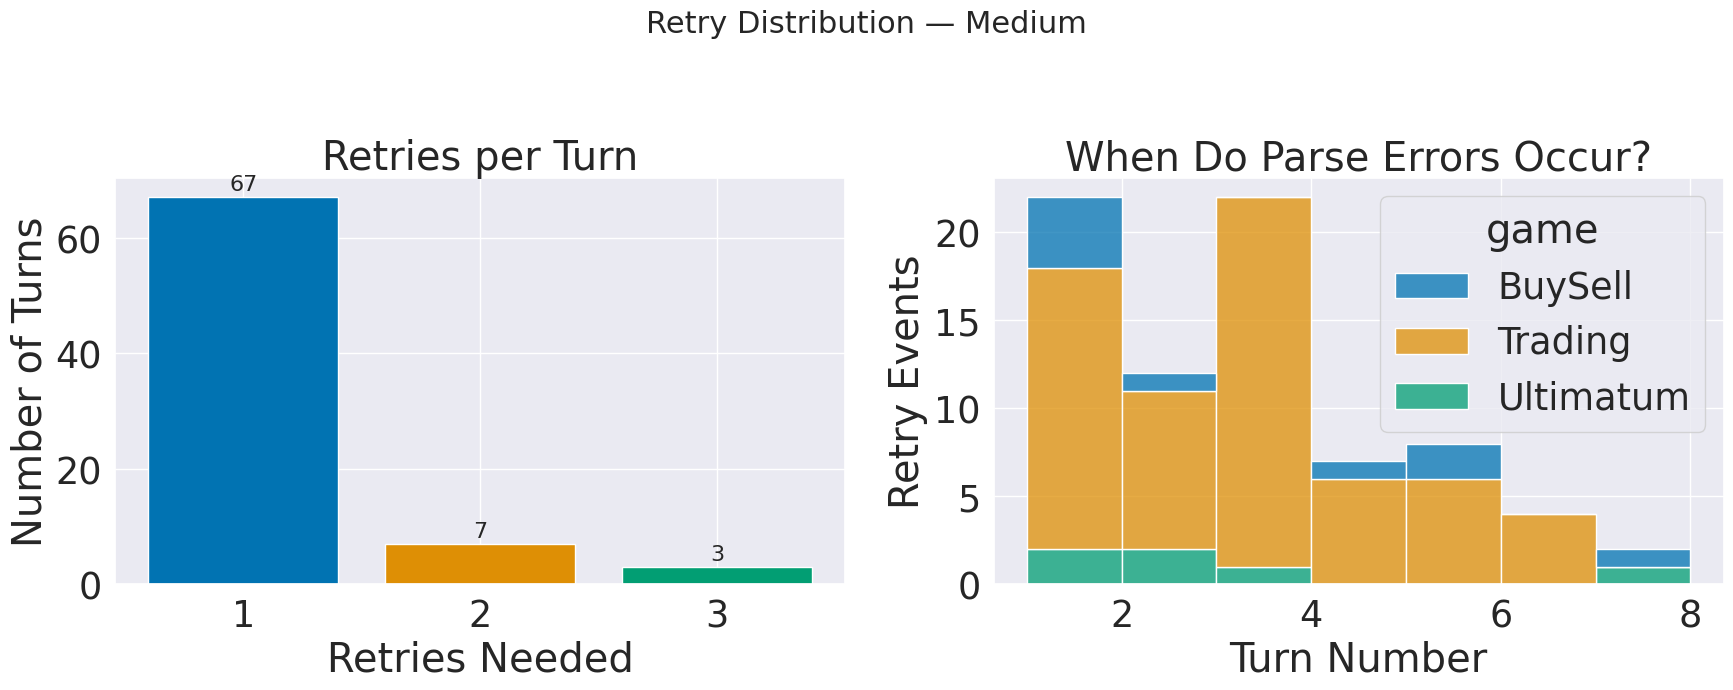

In [37]:
if len(df_retry_all) > 0:
    df_retry = df_retry_all[df_retry_all["condition"] == "Retry (n=3)"].copy()

    # Flatten: one row per turn that needed retries
    retry_turn_rows = []
    for _, row in df_retry.iterrows():
        for turn_idx, retries in enumerate(row["retries_per_turn"]):
            if isinstance(retries, int) and retries > 0:
                retry_turn_rows.append({
                    "game": row["game"],
                    "pairing": row["pairing"],
                    "completed": row["completed"],
                    "turn_idx": turn_idx + 1,
                    "retries_needed": retries,
                })

    df_turns = pd.DataFrame(retry_turn_rows)

    if len(df_turns) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(18, 7))

        # Left: Distribution of retries needed per turn
        ax = axes[0]
        counts = df_turns["retries_needed"].value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values, color=sns.color_palette("colorblind"))
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                    str(val), ha="center", va="bottom", fontsize=16)
        ax.set_xlabel("Retries Needed")
        ax.set_ylabel("Number of Turns")
        ax.set_title("Retries per Turn")
        ax.set_xticks([1, 2, 3])

        # Right: At which turn do retries occur?
        ax = axes[1]
        sns.histplot(data=df_turns, x="turn_idx", hue="game", multiple="stack",
                     bins=range(1, df_turns["turn_idx"].max() + 2), ax=ax, palette="colorblind")
        ax.set_xlabel("Turn Number")
        ax.set_ylabel("Retry Events")
        ax.set_title("When Do Parse Errors Occur?")

        fig.suptitle(f"Retry Distribution — {SIZE_LABEL}", fontsize=22, y=1.02)
        fig.tight_layout()
        plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_retry_distribution.pdf", bbox_inches="tight")
        plt.show()
    else:
        print("No retry events found.")

### Retry Success Rate by Attempt Number

▸ Retry Success by Attempt Number

Total turns entering retry loop: ~211
  (=77 succeeded + ~134 exhausted)

Attempt 1: 67/211 succeeded (31.8%)
Attempt 2: 7/144 succeeded (4.9%)
Attempt 3: 3/137 succeeded (2.2%)

Exhausted all 3 retries: ~134


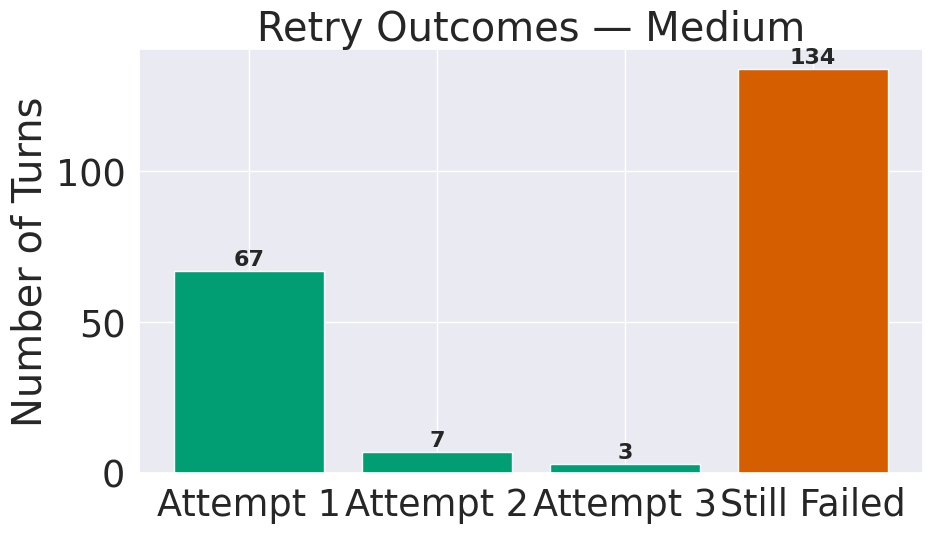

In [38]:
if len(df_retry_all) > 0 and len(df_turns) > 0:
    df_retry = df_retry_all[df_retry_all["condition"] == "Retry (n=3)"].copy()

    succeeded_at = df_turns["retries_needed"].value_counts().sort_index()
    estimated_exhausted = len(df_retry[~df_retry["completed"]])
    total_retry_events = len(df_turns) + estimated_exhausted

    print("▸ Retry Success by Attempt Number\n")
    print(f"Total turns entering retry loop: ~{total_retry_events}")
    print(f"  (={len(df_turns)} succeeded + ~{estimated_exhausted} exhausted)\n")

    attempt_1_success = (df_turns["retries_needed"] == 1).sum()
    attempt_1_total = total_retry_events
    print(f"Attempt 1: {attempt_1_success}/{attempt_1_total} succeeded ({attempt_1_success/attempt_1_total*100:.1f}%)")

    attempt_2_entered = attempt_1_total - attempt_1_success
    attempt_2_success = (df_turns["retries_needed"] == 2).sum()
    if attempt_2_entered > 0:
        print(f"Attempt 2: {attempt_2_success}/{attempt_2_entered} succeeded ({attempt_2_success/attempt_2_entered*100:.1f}%)")

    attempt_3_entered = attempt_2_entered - attempt_2_success
    attempt_3_success = (df_turns["retries_needed"] == 3).sum()
    if attempt_3_entered > 0:
        print(f"Attempt 3: {attempt_3_success}/{attempt_3_entered} succeeded ({attempt_3_success/attempt_3_entered*100:.1f}%)")

    still_failed = attempt_3_entered - attempt_3_success
    print(f"\nExhausted all 3 retries: ~{still_failed}")

    fig, ax = plt.subplots(figsize=(10, 6))
    attempt_labels = ["Attempt 1", "Attempt 2", "Attempt 3", "Still Failed"]
    attempt_vals = [attempt_1_success, attempt_2_success, attempt_3_success, still_failed]
    bar_colors = [sns.color_palette("colorblind")[2]] * 3 + [sns.color_palette("colorblind")[3]]
    bars = ax.bar(attempt_labels, attempt_vals, color=bar_colors)
    for bar, val in zip(bars, attempt_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
                str(val), ha="center", va="bottom", fontsize=16, fontweight="bold")
    ax.set_ylabel("Number of Turns")
    ax.set_title(f"Retry Outcomes — {SIZE_LABEL}")
    fig.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/{MODEL_SIZE}_retry_attempt_success.pdf", bbox_inches="tight")
    plt.show()